In [10]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

In [11]:
# ── parameters ────────────────────────────────────────────────────────────────
TAU_MS     = 500
FS         = 100
SPIKE_T_MS = 300
TOTAL_T_MS = 2500
POLY       = 4
NOISE_STD  = 0.03
WINDOW     = 21

# ── derived ───────────────────────────────────────────────────────────────────
dt     = 1.0 / FS
tau_s  = TAU_MS / 1000.0
N      = int(TOTAL_T_MS / 1000.0 * FS)
sp_idx = int(SPIKE_T_MS / 1000.0 * FS)
t_ms   = np.arange(N) * 1000.0 / FS

In [12]:
# ── signal ────────────────────────────────────────────────────────────────────
np.random.seed(42)
C_true  = np.zeros(N)
for i in range(sp_idx, N):
    C_true[i] = np.exp(-(i - sp_idx) * dt / tau_s)
C_noisy  = C_true + np.random.normal(0, NOISE_STD, N)
C_smooth = savgol_filter(C_noisy, WINDOW, POLY, deriv=0)
C_deriv  = savgol_filter(C_noisy, WINDOW, POLY, deriv=1, delta=dt)
recon    = C_deriv + C_smooth / tau_s

In [13]:
# ── style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "axes.linewidth":    0.8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "legend.fontsize":   8,
    "legend.frameon":    False,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_55776/1840145624.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("$\mathrm{d}C/\mathrm{d}t$  (norm.)")
/tmp/ipykernel_55776/1840145624.py:37: SyntaxWarning: invalid escape sequence '\d'
  lw=1.5, alpha=0.35, label="ideal $\delta(t)$")


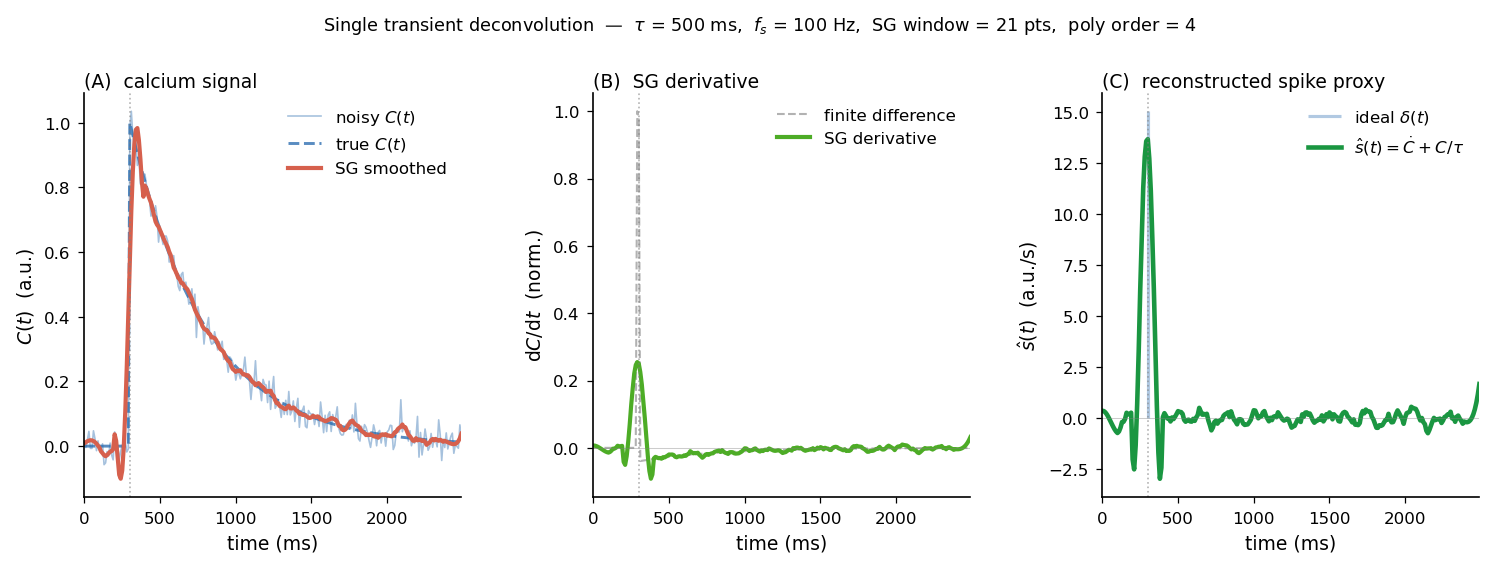

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5),
                          gridspec_kw={"wspace": 0.35})

# ── col 0: calcium signal ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_ms, C_noisy,  color="#2166ac", lw=0.8, alpha=0.4, label="noisy $C(t)$")
ax.plot(t_ms, C_true,   color="#2166ac", lw=1.4, ls="--", alpha=0.75,
        label="true $C(t)$")
ax.plot(t_ms, C_smooth, color="#d6604d", lw=2.0, label="SG smoothed")
ax.axvline(SPIKE_T_MS, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.set_xlim(t_ms[0], t_ms[-1])
ax.set_ylabel("$C(t)$  (a.u.)")
ax.set_xlabel("time (ms)")
ax.set_title("(A)  calcium signal", loc="left", pad=3)
ax.legend(loc="upper right", ncol=1)

# ── col 1: derivative ─────────────────────────────────────────────────────────
ax = axes[1]
exact_dv = np.gradient(C_true, dt)
norm     = np.abs(exact_dv).max()
ax.plot(t_ms, exact_dv / norm, color="gray", lw=1.0, ls="--",
        alpha=0.6, label="finite difference")
ax.plot(t_ms, C_deriv  / norm, color="#4dac26", lw=2.0,
        label="SG derivative")
ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
ax.axvline(SPIKE_T_MS, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.set_xlim(t_ms[0], t_ms[-1])
ax.set_ylabel("$\mathrm{d}C/\mathrm{d}t$  (norm.)")
ax.set_xlabel("time (ms)")
ax.set_title("(B)  SG derivative", loc="left", pad=3)
ax.legend(loc="upper right")

# ── col 2: reconstruction ─────────────────────────────────────────────────────
ax = axes[2]
peak = recon.max()
ax.vlines(SPIKE_T_MS, 0, peak * 1.1, color="#2166ac",
          lw=1.5, alpha=0.35, label="ideal $\delta(t)$")
ax.plot(t_ms, recon, color="#1a9641", lw=2.2,
        label=r"$\hat{s}(t) = \dot{C} + C/\tau$")
ax.axhline(0, color="gray", lw=0.5, alpha=0.4)
ax.axvline(SPIKE_T_MS, color="gray", lw=0.8, ls=":", alpha=0.6)
ax.set_xlim(t_ms[0], t_ms[-1])
ax.set_ylabel(r"$\hat{s}(t)$  (a.u./s)")
ax.set_xlabel("time (ms)")
ax.set_title("(C)  reconstructed spike proxy", loc="left", pad=3)
ax.legend(loc="upper right")

fig.suptitle(
    rf"Single transient deconvolution  —  "
    rf"$\tau$ = {TAU_MS} ms,  $f_s$ = {FS} Hz,  "
    rf"SG window = {WINDOW} pts,  poly order = {POLY}",
    fontsize=8.5, y=1.03
)

plt.show()

In [16]:
fig.savefig("sidelobe.png", dpi=300, bbox_inches="tight")